<a href="https://colab.research.google.com/github/REVATHIPATHI1707/Predictive_Analytics/blob/predictiveanalysis/hospitalcare_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv('ICH_CAHPS_FACILITY.csv')

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')

## Step 1: Identify numeric and categorical columns
# Get numeric columns (excluding CMS certification number and ZIP code)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['cms_certification_number_(ccn)', 'zip_code']]

# Get categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

## Step 2: Fill missing values
# For numeric columns - fill with mean
for col in numeric_cols:
    if df[col].isnull().any():
        col_mean = df[col].mean()
        df[col] = df[col].fillna(col_mean)
        print(f"Filled missing values in {col} with mean: {col_mean:.2f}")

# For categorical columns - fill with mode
for col in categorical_cols:
    if df[col].isnull().any():
        col_mode = df[col].mode()[0]
        df[col] = df[col].fillna(col_mode)
        print(f"Filled missing values in {col} with mode: {col_mode}")

## Step 3: Special handling for specific columns
# For data availability code, we'll keep original missing values as they have meaning
if 'ich_cahps_data_availability_code' in df.columns:
    df['ich_cahps_data_availability_code'] = df['ich_cahps_data_availability_code'].fillna('missing')

# For date fields, we'll keep as is rather than filling with mean/mode
date_cols = [col for col in df.columns if 'date' in col.lower()]
for col in date_cols:
    df[col] = df[col].fillna('unknown')

## Step 4: Verify no missing values remain
print("\nMissing values after imputation:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

# Save the cleaned dataset
df.to_csv('ICH_CAHPS_FACILITY_cleaned.csv', index=False)
print("\nCleaned dataset saved to ICH_CAHPS_FACILITY_cleaned.csv")

Filled missing values in lower_box_percent_of_patients_nephrologists'_communication_and_caring with mean: 18.58
Filled missing values in middle_box_percent_of_patients_nephrologists'_communication_and_caring with mean: 14.58
Filled missing values in top_box_percent_of_patients_nephrologists'_communication_and_caring with mean: 66.84
Filled missing values in linearized_score_of_nephrologists'_communication_and_caring with mean: 80.72
Filled missing values in star_rating_of_nephrologists'_communication_and_caring with mean: 3.03
Filled missing values in lower_box_percent_of_patients_quality_of_dialysis_center_care_and_operations with mean: 17.24
Filled missing values in middle_box_percent_of_patients_quality_of_dialysis_center_care_and_operations with mean: 18.49
Filled missing values in top_box_percent_of_patients_quality_of_dialysis_center_care_and_operations with mean: 64.27
Filled missing values in linearized_score_of_quality_of_dialysis_center_care_and_operations with mean: 80.79
Fi

In [17]:
df = pd.read_csv('ICH_CAHPS_FACILITY_cleaned.csv')
df.head()

,cms_certification_number_(ccn),network,facility_name,address_line_1,address_line_2,city/town,state,zip_code,county/parish,telephone_number,...,linearized_score_of_rating_of_the_dialysis_center_staff,star_rating_of_the_dialysis_center_staff,lower_box_percent_of_patients_rating_of_the_dialysis_facility,middle_box_percent_of_patients_rating_of_the_dialysis_facility,top_box_percent_of_patients_rating_of_the_dialysis_facility,linearized_score_of_rating_of_the_dialysis_facility,star_rating_of_the_dialysis_facility,total_number_of_completed_interviews_from_the_fall_and_spring_surveys,ich_cahps_survey_of_patients'_experiences_star_rating,survey_response_rate
0,12306,8,CHILDRENS HOSPITAL DIALYSIS,1600 7TH AVENUE SOUTH,Suite 100,BIRMINGHAM,AL,35233,Jefferson,(205) 638-9275,...,86.643212,3.001804,11.003157,19.535408,69.461434,87.730266,3.158322,43.473162,3.31935,26.967975
1,12500,8,FMC CAPITOL CITY,255 S JACKSON STREET,Suite 100,MONTGOMERY,AL,36104,Montgomery,(334) 263-1028,...,79.000000,2.000000,25.000000,19.000000,56.000000,80.000000,1.000000,40.000000,3.00000,23.000000
2,12501,8,DaVita Gadsden Dialysis,409 SOUTH FIRST STREET,Suite 100,GADSDEN,AL,35901,Etowah,(256) 547-2511,...,86.643212,3.001804,11.003157,19.535408,69.461434,87.730266,3.158322,43.473162,3.31935,26.967975
3,12502,8,DaVita Tuscaloosa University Dialysis,220 15TH STREET,Suite 100,TUSCALOOSA,AL,35401,Tuscaloosa,(205) 345-6004,...,86.643212,3.001804,11.003157,19.535408,69.461434,87.730266,3.158322,43.473162,3.31935,26.967975
4,12505,8,DaVita PDI-Montgomery,1001 FOREST AVENUE,Suite 100,MONTGOMERY,AL,36106,Montgomery,(334) 269-9416,...,86.643212,3.001804,11.003157,19.535408,69.461434,87.730266,3.158322,43.473162,3.31935,26.967975


=== Dialysis Facility Performance Analysis ===

Top 10 Facilities Nationally by Patient Experience:
                                  facility_name            city/town state profit_or_non_profit     chain_organization  overall_patient_experience  total_number_of_completed_interviews_from_the_fall_and_spring_surveys  survey_response_rate
              Mohan Dialysis Center of Industry     City of Industry    CA               profit            Independent                         5.0                                                                  144.0                  52.0
       FMC RENAL CARE OF NORTHERN NEW YORK, LLC            WATERTOWN    NY               profit Fresenius Medical Care                         5.0                                                                   44.0                  27.0
                   DaVita Orchard Park Dialysis         ORCHARD PARK    NY               profit                 DaVita                         5.0                                  

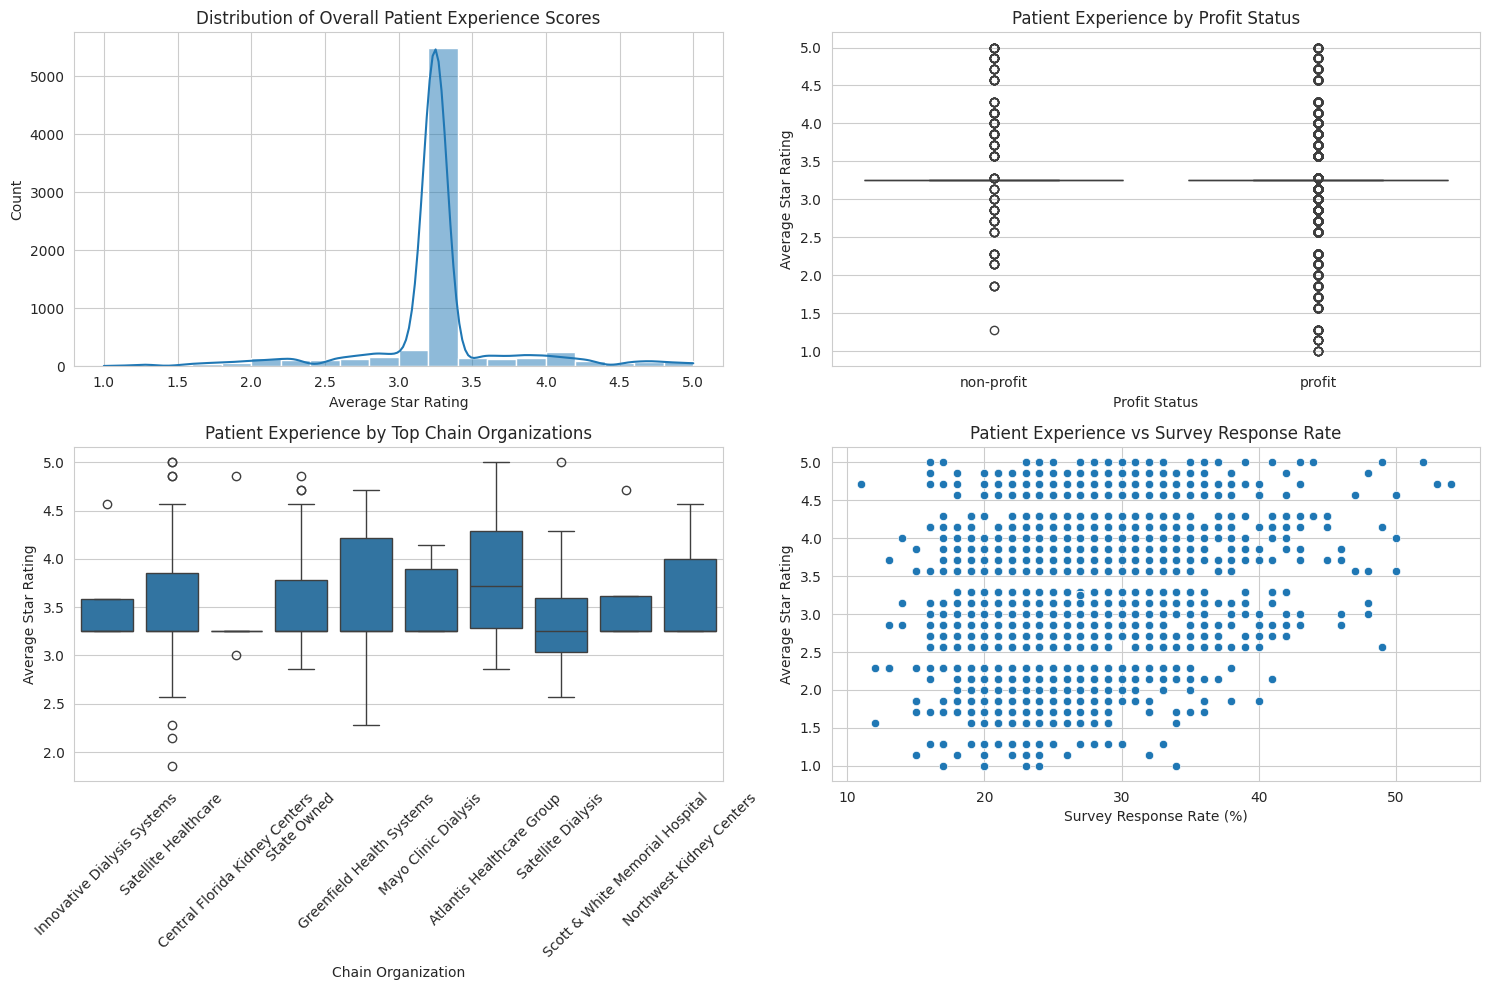


Correlation Matrix for Key Metrics:
                                                    overall_patient_experience  \
overall_patient_experience                                            1.000000   
survey_response_rate                                                  0.269721   
total_number_of_completed_interviews_from_the_f...                   -0.019078   

                                                    survey_response_rate  \
overall_patient_experience                                      0.269721   
survey_response_rate                                            1.000000   
total_number_of_completed_interviews_from_the_f...              0.152204   

                                                    total_number_of_completed_interviews_from_the_fall_and_spring_surveys  
overall_patient_experience                                                                  -0.019078                      
survey_response_rate                                                             

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
df = pd.read_csv('ICH_CAHPS_FACILITY_cleaned.csv')

## Data Preparation
# Clean column names (if needed)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')

# Convert star ratings to numeric (if not already)
star_rating_cols = [col for col in df.columns if 'star_rating' in col]
for col in star_rating_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Create an overall patient experience score (average of all star ratings)
df['overall_patient_experience'] = df[star_rating_cols].mean(axis=1)

# Clean categorical variables
df['profit_or_non_profit'] = df['profit_or_non_profit'].str.strip().str.lower()
df['chain_owned'] = df['chain_owned'].str.strip().str.lower()

## Analysis Functions
def get_top_facilities(df, n=10, state=None):
    """Return top n facilities by overall patient experience, optionally filtered by state"""
    if state:
        filtered = df[df['state'] == state.upper()].copy()
    else:
        filtered = df.copy()

    return filtered.sort_values('overall_patient_experience', ascending=False).head(n)[[
        'facility_name',
        'city/town',
        'state',
        'profit_or_non_profit',
        'chain_organization',
        'overall_patient_experience',
        'total_number_of_completed_interviews_from_the_fall_and_spring_surveys',
        'survey_response_rate'
    ]]

def analyze_performance_trends(df):
    """Analyze performance trends by different categories"""
    results = {}

    # By profit status
    results['profit_status'] = df.groupby('profit_or_non_profit')['overall_patient_experience'].agg(['mean', 'median', 'count'])

    # By chain organization (top 10)
    chain_stats = df.groupby('chain_organization')['overall_patient_experience'].agg(['mean', 'median', 'count'])
    results['chain_org'] = chain_stats.sort_values('mean', ascending=False).head(10)

    # By state
    results['by_state'] = df.groupby('state')['overall_patient_experience'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)

    return results

def plot_performance_distribution(df):
    """Visualize the distribution of performance metrics"""
    plt.figure(figsize=(15, 10))

    # Overall distribution
    plt.subplot(2, 2, 1)
    sns.histplot(df['overall_patient_experience'], bins=20, kde=True)
    plt.title('Distribution of Overall Patient Experience Scores')
    plt.xlabel('Average Star Rating')

    # By profit status
    plt.subplot(2, 2, 2)
    sns.boxplot(x='profit_or_non_profit', y='overall_patient_experience', data=df)
    plt.title('Patient Experience by Profit Status')
    plt.xlabel('Profit Status')
    plt.ylabel('Average Star Rating')

    # By chain organization (top 10)
    top_chains = df.groupby('chain_organization')['overall_patient_experience'].mean().sort_values(ascending=False).head(10).index
    chain_data = df[df['chain_organization'].isin(top_chains)]
    plt.subplot(2, 2, 3)
    sns.boxplot(x='chain_organization', y='overall_patient_experience', data=chain_data)
    plt.title('Patient Experience by Top Chain Organizations')
    plt.xlabel('Chain Organization')
    plt.ylabel('Average Star Rating')
    plt.xticks(rotation=45)

    # By response rate
    plt.subplot(2, 2, 4)
    sns.scatterplot(x='survey_response_rate', y='overall_patient_experience', data=df)
    plt.title('Patient Experience vs Survey Response Rate')
    plt.xlabel('Survey Response Rate (%)')
    plt.ylabel('Average Star Rating')

    plt.tight_layout()
    plt.show()

## Execute Analysis
if __name__ == "__main__":
    print("=== Dialysis Facility Performance Analysis ===")

    # 1. Get top facilities nationally
    print("\nTop 10 Facilities Nationally by Patient Experience:")
    print(get_top_facilities(df).to_string(index=False))

    # 2. Get top facilities in a specific state (e.g., CA)
    print("\nTop 5 Facilities in California by Patient Experience:")
    print(get_top_facilities(df, n=5, state='CA').to_string(index=False))

    # 3. Analyze performance trends
    trends = analyze_performance_trends(df)
    print("\nPerformance by Profit Status:")
    print(trends['profit_status'])
    print("\nPerformance by Top Chain Organizations:")
    print(trends['chain_org'])
    print("\nPerformance by State:")
    print(trends['by_state'].head(10))  # Just show top 10 states

    # 4. Visualize distributions
    plot_performance_distribution(df)

    # 5. Correlation analysis
    print("\nCorrelation Matrix for Key Metrics:")
    corr_matrix = df[[
        'overall_patient_experience',
        'survey_response_rate',
        'total_number_of_completed_interviews_from_the_fall_and_spring_surveys'
    ]].corr()
    print(corr_matrix)

    # 6. Save analysis results
    trends['by_state'].to_csv('state_performance_analysis.csv')
    trends['chain_org'].to_csv('chain_organization_performance.csv')
    print("\nAnalysis results saved to CSV files.")